In [14]:
# Imports and paths
from pathlib import Path
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from skimage import io, filters, morphology, exposure, color
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from time import perf_counter
from torch.cuda.amp import autocast

In [15]:
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 12
# Paths (update as needed)
REP_DIR = Path('process/train-512-lv1')  # 30 tiles with four categories inside subfolders
FULL_DATA_DIR = Path('process/tile/level-train-batch4')     # root with large 2k tiles
MASK_CACHE_DIR = Path('process/output')         # where generated full-size masks will be stored
MASK_CACHE_DIR.mkdir(parents=True, exist_ok=True)
CROP_SIZE = 512
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Step 0 – 載入並視覺化 30 個代表性圖塊

strong 10 files found
weak 5 files found
negative 10 files found
blank 5 files found


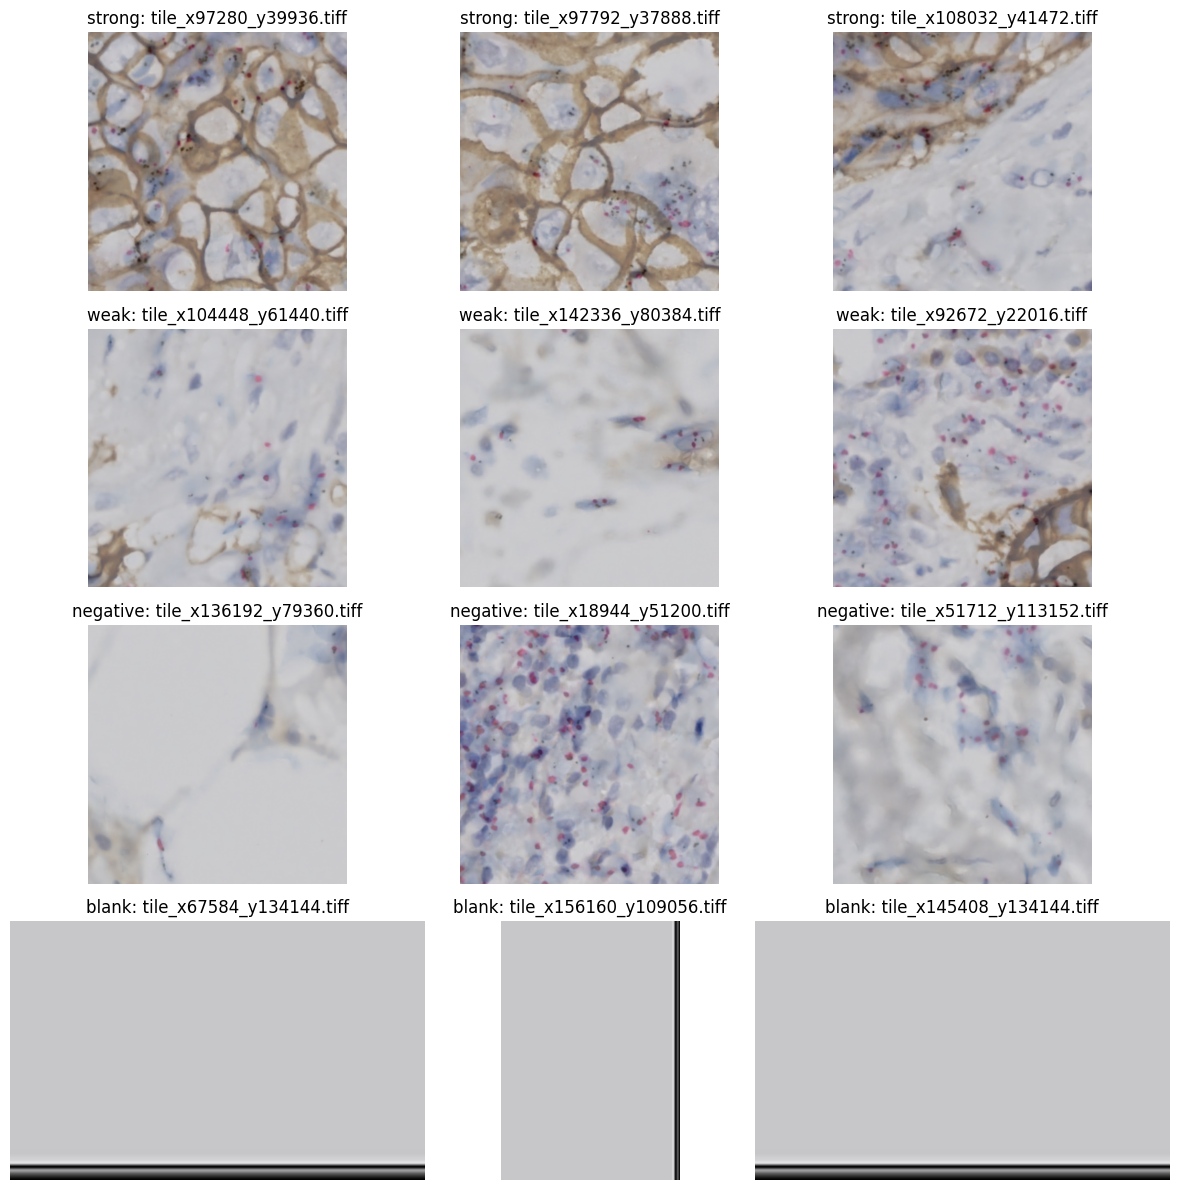

In [16]:
# Collect representative tiles by category and show a small grid
CATEGORY_ALIASES = {
    'strong': ['strong', 'strong_positive', '3plus', '3+'],
    'weak': ['weak', 'weak_brown', '1plus', '2plus'],
    'negative': ['negative', 'neg'],
    'blank': ['blank', 'empty', 'white']
}

def collect_category_files(base_dir: Path, aliases: dict, limit: int | None = None):
    paths_by_cat = {}
    for cat, names in aliases.items():
        candidates = []
        for name in names:
            for ext in ('*.png', '*.jpg', '*.jpeg', '*.tif', '*.tiff'):
                candidates.extend(sorted((base_dir / name).glob(ext)))
        # unique while preserving order
        seen = set()
        unique_paths = []
        for p in candidates:
            if p not in seen:
                unique_paths.append(p)
                seen.add(p)
        if limit is not None:
            unique_paths = unique_paths[:limit]
        paths_by_cat[cat] = unique_paths
    return paths_by_cat

rep_paths_by_cat = collect_category_files(REP_DIR, CATEGORY_ALIASES, limit=10)
for cat, paths in rep_paths_by_cat.items():
    print(cat, len(paths), 'files found')

def show_representative_grid(paths_by_cat: dict, samples_per_cat: int = 3):
    fig, axes = plt.subplots(len(paths_by_cat), samples_per_cat, figsize=(4 * samples_per_cat, 3 * len(paths_by_cat)))
    if len(paths_by_cat) == 1:
        axes = np.expand_dims(axes, 0)
    for row_idx, (cat, paths) in enumerate(paths_by_cat.items()):
        selected = random.sample(paths, k=min(samples_per_cat, len(paths))) if paths else []
        for col_idx in range(samples_per_cat):
            ax = axes[row_idx, col_idx] if paths_by_cat else axes[col_idx]
            if col_idx < len(selected):
                img = np.array(Image.open(selected[col_idx]).convert('RGB'))
                ax.imshow(img)
                ax.set_title(f"{cat}: {selected[col_idx].name}")
            else:
                ax.axis('off')
            ax.axis('off')
    plt.tight_layout()
    plt.show()

show_representative_grid(rep_paths_by_cat, samples_per_cat=3)

### Step 1 – Calibrate pseudo-mask generator
運行預覽單元格，並在繼續操作之前，透過視覺確認它是否抑制了負面/空白圖塊並保留了弱/強環。

In [17]:
def _read_rgb_uint8(path: Path) -> np.ndarray:
    img = io.imread(path)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    if img.shape[2] == 4:
        img = img[..., :3]
    if img.dtype != np.uint8:
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    return img
#generate_pseudo_mask

In [7]:
def generate_pseudo_mask(image_path: Path) -> np.ndarray:
    """
    生成三类别的pseudo mask
    0 = 背景（细胞外）
    1 = 细胞内部（闭环内）
    2 = 细胞膜（棕色边缘）
    """
    img = _read_rgb_uint8(image_path)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    
    # 检测棕色区域
    lower_brown = np.array([0, 30, 40], dtype=np.uint8)
    upper_brown = np.array([30, 150, 160], dtype=np.uint8)
    mask_brown = cv2.inRange(hsv, lower_brown, upper_brown)
    
    # 形态学处理清理噪点
    kernel_open = np.ones((3, 3), np.uint8)
    kernel_close = np.ones((5, 5), np.uint8)
    mask_brown = cv2.morphologyEx(mask_brown, cv2.MORPH_OPEN, kernel_open)
    mask_brown = cv2.morphologyEx(mask_brown, cv2.MORPH_CLOSE, kernel_close)
    
    # ===== 关键改进：区分细胞膜和细胞内 =====
    # 1. 填充孔洞得到完整细胞区域
    from scipy import ndimage
    mask_filled = ndimage.binary_fill_holes(mask_brown).astype(np.uint8) * 255
    
    # 2. 细胞内部 = 填充后的区域 - 原始棕色区域
    mask_inside = cv2.subtract(mask_filled, mask_brown)
    
    # 3. 生成三类别mask
    final_mask = np.zeros_like(mask_brown, dtype=np.uint8)
    final_mask[mask_inside > 0] = 1  # 细胞内部
    final_mask[mask_brown > 0] = 2   # 细胞膜（棕色区域）
    # 背景保持为0
    
    return final_mask

C:\Users\user\AppData\Local\Temp\ipykernel_28976\2536753512.py:49: UserWarning: Glyph 32972 (\N{CJK UNIFIED IDEOGRAPH-80CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_28976\2536753512.py:49: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_28976\2536753512.py:49: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_28976\2536753512.py:49: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_28976\2536753512.py:49: UserWarning: Glyph 33180 (\N{CJK UNIFIED IDEOGRAPH-819C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
e:\Class\tsgh\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32972 (\N{C

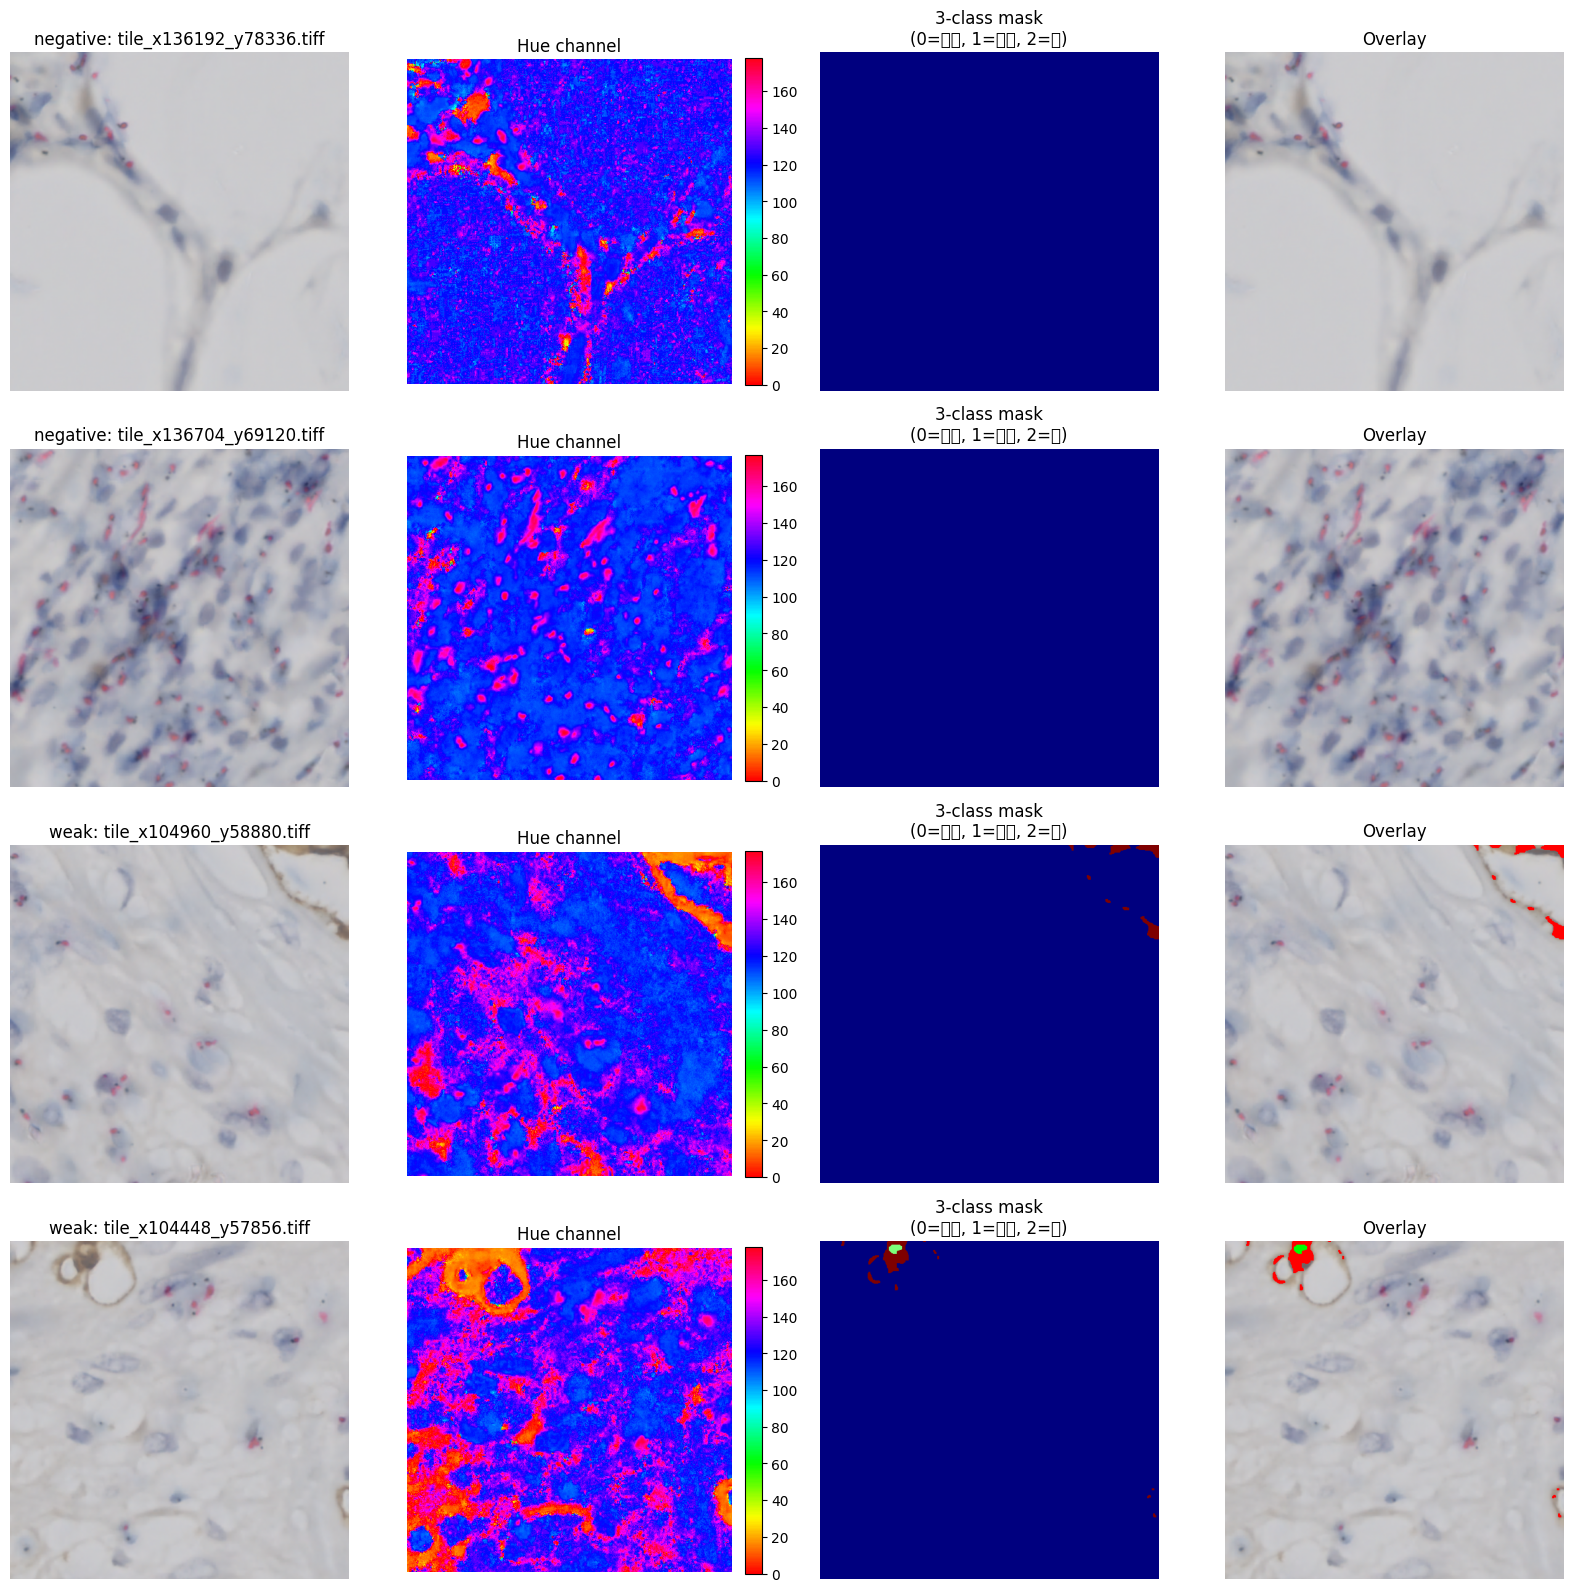

In [8]:
# Validate HSV-based pseudo-mask on negative and weak samples with Hue visualization
def preview_hsv_masks(paths_by_cat: dict, categories=('negative', 'weak'), samples_per_cat: int = 2):
    selected_items = []
    for cat in categories:
        if cat not in paths_by_cat:
            continue
        paths = paths_by_cat.get(cat, [])
        chosen = random.sample(paths, k=min(samples_per_cat, len(paths))) if paths else []
        for p in chosen:
            selected_items.append((cat, p))
    
    rows = len(selected_items)
    if rows == 0:
        print('No samples found for categories:', categories)
        return
    
    fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))  # 改成4列
    if rows == 1:
        axes = np.expand_dims(axes, 0)
    
    for i, (cat, p) in enumerate(selected_items):
        img = _read_rgb_uint8(p)
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        hue = hsv[..., 0]
        mask = generate_pseudo_mask(p)
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{cat}: {p.name}")
        axes[i, 0].axis('off')
        
        im1 = axes[i, 1].imshow(hue, cmap='hsv')
        axes[i, 1].set_title('Hue channel')
        axes[i, 1].axis('off')
        fig.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)
        
        # 显示三类别mask（用不同颜色）
        axes[i, 2].imshow(mask, cmap='jet', vmin=0, vmax=2)
        axes[i, 2].set_title('3-class mask\n(0=背景, 1=内部, 2=膜)')
        axes[i, 2].axis('off')
        
        # 叠加显示
        overlay = img.copy()
        overlay[mask == 1] = [0, 255, 0]  # 绿色=内部
        overlay[mask == 2] = [255, 0, 0]  # 红色=膜
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Overlay')
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.show()

preview_hsv_masks(rep_paths_by_cat, categories=('negative', 'weak'), samples_per_cat=2)

### Step 2 – 具有磁碟遮罩快取與 2k 影像隨機裁切的資料集

In [20]:
# Dataset for large images (e.g., 2048x2048) with cached full-size masks and on-the-fly 512x512 crops
class LargeImagePseudoMaskDataset(Dataset):
    def __init__(self, image_root: Path, mask_root: Path, transform=None, cache_ext: str = '.png', crop_size: int = 512, center_crop_val: bool = False):
        self.image_root = image_root
        self.mask_root = mask_root
        self.transform = transform
        self.cache_ext = cache_ext
        self.crop_size = crop_size
        self.center_crop_val = center_crop_val
        self.samples = sorted([p for p in image_root.rglob('*') if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.tif', '.tiff')])
        if not self.samples:
            raise RuntimeError(f'No images found under {image_root}')
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx: int):
        img_path = self.samples[idx]
        rel = img_path.relative_to(self.image_root)
        mask_path = (self.mask_root / rel).with_suffix(self.cache_ext)
        mask_path.parent.mkdir(parents=True, exist_ok=True)
        img = np.array(Image.open(img_path).convert('RGB'))
        if mask_path.exists():
            mask = np.array(Image.open(mask_path))
        else:
            mask = generate_pseudo_mask(img_path)
            Image.fromarray(mask).save(mask_path)
        # Apply crop + augmentations
        if self.transform is not None:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
            elif mask.ndim == 3 and mask.shape[0] != 1:
                mask = mask.permute(2, 0, 1)
            mask = mask.float() / 255.0
        else:
            img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask).unsqueeze(0).float() / 255.0
        return img, mask

# Training transform: random crop to 512 then augment
# 加入 PadIfNeeded 處理小於 512x512 的圖片
train_transform = A.Compose([
    A.PadIfNeeded(min_height=CROP_SIZE, min_width=CROP_SIZE, 
                  border_mode=cv2.BORDER_REFLECT_101),
    A.RandomCrop(height=CROP_SIZE, width=CROP_SIZE),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    A.ElasticTransform(alpha=50, sigma=5, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Validation transform: deterministic center crop then normalize
# 加入 PadIfNeeded 處理小於 512x512 的圖片
val_transform = A.Compose([
    A.PadIfNeeded(min_height=CROP_SIZE, min_width=CROP_SIZE,
                  border_mode=cv2.BORDER_REFLECT_101),
    A.CenterCrop(height=CROP_SIZE, width=CROP_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


### Step 3 – U-Net 模型（segmentation_models_pytorch）和損失函數

In [21]:
# Model, losses, and metrics
model = smp.Unet(
    encoder_name='efficientnet-b4',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None
).to(device)

dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
focal_loss = smp.losses.FocalLoss(mode='binary')

def loss_fn(pred, target):
    return dice_loss(pred, target) + focal_loss(pred, target)

def iou_score(pred, target, threshold: float = 0.5, eps: float = 1e-6):
    probs = torch.sigmoid(pred)
    pred_bin = (probs > threshold).float()
    target_bin = (target > threshold).float()
    intersection = (pred_bin * target_bin).sum(dim=(1, 2, 3))
    union = pred_bin.sum(dim=(1, 2, 3)) + target_bin.sum(dim=(1, 2, 3)) - intersection
    return ((intersection + eps) / (union + eps)).mean().item()

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)


# 

### Step 4 & 5 – 在代表性資料集上進行驗證的訓練循環

In [22]:
from torch.cuda.amp import autocast, GradScaler
# ========== 1. 預載入資料集類別 ==========
class PreloadedDataset(torch.utils.data.Dataset):
    """將整個 dataset 預載入到 RAM，消除 I/O 瓶頸"""
    def __init__(self, base_dataset, desc="Loading"):
        print(f"[{desc}] 預載入 {len(base_dataset)} 個樣本到 RAM...")
        t0 = perf_counter()
        self.data = []
        for i in range(len(base_dataset)):
            self.data.append(base_dataset[i])
            if (i + 1) % 2000 == 0:
                print(f"  已載入 {i+1}/{len(base_dataset)}...")
        print(f"[{desc}] 完成！耗時 {perf_counter()-t0:.1f}s")
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    def __len__(self):
        return len(self.data)

# ========== 2. 創建 AMP GradScaler ==========
scaler = GradScaler(enabled=(device.type == 'cuda'))

/tmp/ipykernel_282751/293816244.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == 'cuda'))


In [23]:
# ========== 3. 優化的訓練函數（使用 AMP 混合精度）==========
def train_one_epoch(loader, model, optimizer, device):
    model.train()
    print('Training on device:', device)
    running_loss = 0.0
    running_iou = 0.0
    batch_times = []
    
    for imgs, masks in loader:
        t0 = perf_counter()
        
        # 使用 non_blocking 加速數據傳輸
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        # 使用 set_to_none=True 比 zero_grad() 更快
        optimizer.zero_grad(set_to_none=True)
        
        # AMP: 自動混合精度訓練
        with autocast():
            preds = model(imgs)
            loss = loss_fn(preds, masks)
        
        # 縮放梯度並反向傳播
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * imgs.size(0)
        with torch.no_grad():
            running_iou += iou_score(preds.detach(), masks)
        
        batch_times.append(perf_counter() - t0)
    
    avg_bt = float(np.mean(batch_times)) if batch_times else 0.0
    return running_loss / len(loader.dataset), running_iou / len(loader), avg_bt

In [24]:
# ========== 4. 優化的評估函數 ==========
@torch.no_grad()
def evaluate(loader, model, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    
    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        with autocast():
            preds = model(imgs)
            loss = loss_fn(preds, masks)
        
        running_loss += loss.item() * imgs.size(0)
        running_iou += iou_score(preds, masks)
    
    return running_loss / len(loader.dataset), running_iou / len(loader)

In [25]:
# ========== 5. 資料集設置 ==========
full_ds_train = LargeImagePseudoMaskDataset(
    FULL_DATA_DIR,
    MASK_CACHE_DIR,
    transform=train_transform
)
full_ds_val = LargeImagePseudoMaskDataset(
    FULL_DATA_DIR,
    MASK_CACHE_DIR,
    transform=val_transform
)

num_samples = len(full_ds_train)
train_size = int(0.9 * num_samples)
val_size = num_samples - train_size
indices = torch.randperm(
    num_samples,
    generator=torch.Generator().manual_seed(0)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_ds = torch.utils.data.Subset(full_ds_train, train_indices)
val_ds = torch.utils.data.Subset(full_ds_val, val_indices)

In [26]:
# ========== 6. 預載入資料到 RAM（核心優化！）==========
print("=" * 60)
print("開始預載入資料到 RAM... (請等待 1-3 分鐘)")
print("這將大幅提升 GPU 使用率！")
print("=" * 60)

train_ds_preloaded = PreloadedDataset(train_ds, desc="Train")
val_ds_preloaded = PreloadedDataset(val_ds, desc="Val")

# Representative set
rep_mask_dir = MASK_CACHE_DIR / 'rep_eval'
rep_mask_dir.mkdir(parents=True, exist_ok=True)
rep_ds = LargeImagePseudoMaskDataset(
    REP_DIR,
    rep_mask_dir,
    transform=val_transform
)
rep_ds_preloaded = PreloadedDataset(rep_ds, desc="Rep")
BATCH_SIZE = 32
train_loader = DataLoader(
    train_ds_preloaded,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # 資料在 RAM，不需要 workers
    pin_memory=True
)
val_loader = DataLoader(
    val_ds_preloaded,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
rep_loader = DataLoader(
    rep_ds_preloaded,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

開始預載入資料到 RAM... (請等待 1-3 分鐘)
這將大幅提升 GPU 使用率！
[Train] 預載入 9000 個樣本到 RAM...
  已載入 2000/9000...
  已載入 4000/9000...
  已載入 6000/9000...
  已載入 8000/9000...
[Train] 完成！耗時 231.5s
[Val] 預載入 1000 個樣本到 RAM...
[Val] 完成！耗時 36.1s
[Rep] 預載入 33 個樣本到 RAM...
[Rep] 完成！耗時 0.2s


In [27]:
print(f"\n優化設置:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Num workers: 0 (資料已在 RAM)")
print(f"  使用 AMP 混合精度: True")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Rep batches: {len(rep_loader)}")


優化設置:
  Batch size: 32
  Num workers: 0 (資料已在 RAM)
  使用 AMP 混合精度: True
  Train batches: 282
  Val batches: 32
  Rep batches: 2


In [ ]:
# ========== 8. 開始訓練 ==========
num_epochs = 30
print('\n' + "=" * 60)
print('開始訓練...')
print("=" * 60)

for epoch in range(num_epochs):
    epoch_start = perf_counter()
    train_loss, train_iou, train_bt = train_one_epoch(
        train_loader,
        model,
        optimizer,
        device
    )
    val_loss, val_iou = evaluate(val_loader, model, device)
    rep_loss, rep_iou = evaluate(rep_loader, model, device)
    lr_scheduler.step(val_iou)
    epoch_time = perf_counter() - epoch_start
    print(
        f"Epoch {epoch+1:2d}/{num_epochs}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"val_iou={val_iou:.3f} rep_iou={rep_iou:.3f} "
        f"train_bt={train_bt*1000:.1f}ms/batch epoch={epoch_time:.1f}s"
    )
# 


開始訓練...
Training on device: cuda


/tmp/ipykernel_282751/4106629730.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_282751/829412175.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch  1/30: train_loss=0.3747 val_loss=0.2021 val_iou=0.747 rep_iou=0.759 train_bt=264.3ms/batch epoch=90.4s
Training on device: cuda
Epoch  2/30: train_loss=0.1342 val_loss=0.0830 val_iou=0.854 rep_iou=0.874 train_bt=223.2ms/batch epoch=77.1s
Training on device: cuda
Epoch  3/30: train_loss=0.1047 val_loss=0.0754 val_iou=0.856 rep_iou=0.904 train_bt=223.2ms/batch epoch=76.4s
Training on device: cuda
Epoch  4/30: train_loss=0.0914 val_loss=0.0764 val_iou=0.850 rep_iou=0.907 train_bt=223.3ms/batch epoch=77.6s
Training on device: cuda
Epoch  5/30: train_loss=0.0821 val_loss=0.0661 val_iou=0.872 rep_iou=0.888 train_bt=223.3ms/batch epoch=76.0s
Training on device: cuda
Epoch  6/30: train_loss=0.0758 val_loss=0.0832 val_iou=0.834 rep_iou=0.896 train_bt=223.2ms/batch epoch=75.5s
Training on device: cuda
Epoch  7/30: train_loss=0.0722 val_loss=0.0817 val_iou=0.845 rep_iou=0.835 train_bt=223.3ms/batch epoch=76.5s
Training on device: cuda
Epoch  8/30: train_loss=0.0704 val_loss=0.0612 val_iou=

In [ ]:
MODEL_DIR = Path("process/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
# Save trained model checkpoint
ckpt = {
    "epoch": num_epochs,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scaler_state": scaler.state_dict() if scaler is not None else None,
    "val_iou": val_iou,
    "rep_iou": rep_iou,
}
print(ckpt)
ckpt_path = MODEL_DIR / f"unet3.pt"
torch.save(ckpt, ckpt_path)
print(f"Checkpoint saved to: {ckpt_path.resolve()}")

### Step 6 – 2k 影像的滑動視窗推論與可視化

# 測試+屍體區

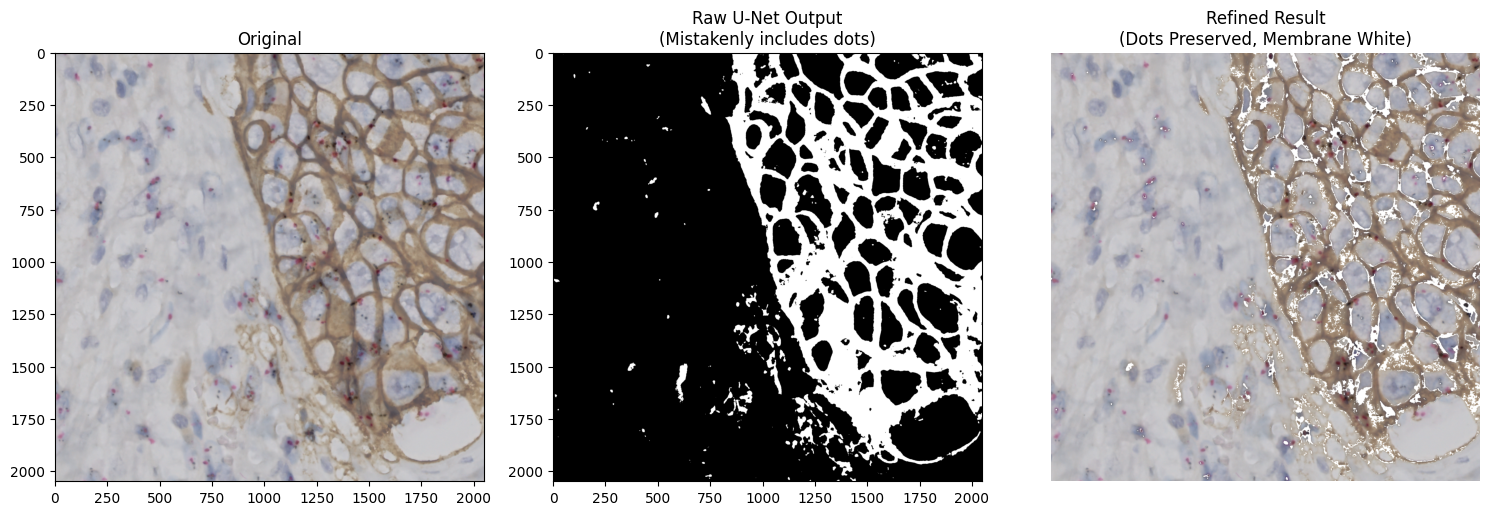

In [ ]:
def refine_unet_output(original_img, unet_mask_prediction):
    """
    original_img: 原始 RGB 影像
    unet_mask_prediction: U-Net 輸出的細胞膜 Mask (0 or 255/1)
    """
    # 轉 HSV 空間以鎖定紅/黑點
    hsv = cv2.cvtColor(original_img, cv2.COLOR_RGB2HSV)
    
    # 1. 建立「絕對紅點」遮罩 (Red Dot Mask)
    # 紅色在 HSV 跨越 0 度，需取兩段
    lower_red1 = np.array([0, 40, 40])
    upper_red1 = np.array([15, 255, 255])
    lower_red2 = np.array([160, 40, 40])
    upper_red2 = np.array([180, 255, 255])
    
    mask_red = cv2.bitwise_or(
        cv2.inRange(hsv, lower_red1, upper_red1), 
        cv2.inRange(hsv, lower_red2, upper_red2)
    )
    
    # 2. 建立「絕對黑點」遮罩 (Black Dot Mask)
    # 黑色：亮度 (Value) 極低，飽和度 (Saturation) 不限
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([180, 80, 80]) 
    mask_black = cv2.inRange(hsv, lower_black, upper_black)
    
    # 合併保護區：這些區域絕對不是膜
    mask_dots_protection = cv2.bitwise_or(mask_red, mask_black)
    
    # 膨脹保護區一點點，確保邊緣不會被吃到 (Optional)
    kernel = np.ones((3,3), np.uint8)
    mask_dots_protection = cv2.dilate(mask_dots_protection, kernel, iterations=1)
    
    # 3. 修正 U-Net 的預測
    # 邏輯：雖然 U-Net 說是膜，但如果是紅/黑點，就「否決」它
    # final_mask = unet_mask AND (NOT dot_mask)
    final_membrane_mask = cv2.subtract(unet_mask_prediction, mask_dots_protection)
    
    # 4. 產生結果圖
    result_img = original_img.copy()
    # 只有在「修正後的 Mask」區域才塗白
    # 這樣原本是紅點的地方，因為被從 Mask 中移除了，所以會保留原圖的紅點顏色
    result_img[final_membrane_mask > 0] = [255, 255, 255]
    
    return result_img, final_membrane_mask

# --- 模擬使用範例 ---
# 假設您已經跑完 U-Net 得到 pred_mask
# image = ...
# pred_mask = model.predict(image) ...

# 這裡我用前面生成的 mask 模擬您的 U-Net 輸出
# (在您的程式中，請直接傳入 model 的輸出 mask)
import cv2
img = cv2.imread('process/tile/tile_x153600_y59392.tiff')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 模擬一個不完美的 U-Net Mask (這裡假設它連紅點都圈進去了)
# 為了演示，我們重新生成一個包含所有棕色與紅色的 Mask
from skimage.color import rgb2hed
from skimage.exposure import rescale_intensity
ihc_hed = rgb2hed(img_rgb)
dab = rescale_intensity(ihc_hed[:, :, 2], out_range=(0, 255)).astype(np.uint8)
_, simulated_unet_mask = cv2.threshold(dab, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
# 這個 simulated_unet_mask 現在包含了膜，但也包含了部分紅點（錯誤）

# 執行修正
result_img, refined_mask = refine_unet_output(img_rgb, simulated_unet_mask)

# 顯示比較
fig, ax = plt.subplots(1, 3, figsize=(15, 6))
ax[0].imshow(img_rgb)
ax[0].set_title("Original")
ax[1].imshow(simulated_unet_mask, cmap='gray')
ax[1].set_title("Raw U-Net Output\n(Mistakenly includes dots)")
ax[2].imshow(result_img)
ax[2].set_title("Refined Result\n(Dots Preserved, Membrane White)")
plt.axis('off')
plt.tight_layout()
plt.savefig('unet_refinement_demo.png')
plt.show()